In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv


# End to End Sales Forecasting & Demand Intelligence System

### Internship Project - Week 3 & Week 4

**Name:** Kanchan

---

## Project Overview

Retail businesses depend on accurate sales forecasting to maintain optimal inventory levels and improve customer satisfaction. Overstocking increases storage costs while understocking results in lost sales opportunities.

This project develops a complete Sales Forecasting and Demand Intelligence System using historical Superstore sales data.

The project includes:

- Data exploration and feature engineering
- Time series decomposition
- Sales forecasting using SARIMA, Prophet, and XGBoost
- Product and regional forecasting
- Anomaly detection
- Product demand segmentation
- Interactive Streamlit dashboard
- Executive business report

---

## Objectives

- Analyze historical sales patterns
- Identify seasonality and long-term trends
- Forecast future sales for the next three months
- Detect abnormal sales behavior
- Segment products based on demand characteristics
- Build an interactive dashboard for business decision-making

In [2]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from prophet import Prophet
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_palette("Set2")

# Data Loading & Deep Exploration

In [3]:
df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df.shape

(9800, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [9]:

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [10]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = df["Order Date"].dt.quarter

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

df["Season"] = df["Month"].map({
    12:"Winter",1:"Winter",2:"Winter",
    3:"Spring",4:"Spring",5:"Spring",
    6:"Summer",7:"Summer",8:"Summer",
    9:"Autumn",10:"Autumn",11:"Autumn"
})

In [11]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Quarter           0
Week              0
Day               0
Season            0
dtype: int64

only postal code have 11 null values 

In [12]:
df.duplicated().sum()

np.int64(0)

no dulicates

In [13]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [20]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)


weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)


monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
    .sum()
    .reset_index()
)

print("Daily Sales Shape :", daily_sales.shape)
print("Weekly Sales Shape:", weekly_sales.shape)
print("Monthly Sales Shape:", monthly_sales.shape)

Daily Sales Shape : (1230, 2)
Weekly Sales Shape: (209, 2)
Monthly Sales Shape: (48, 2)


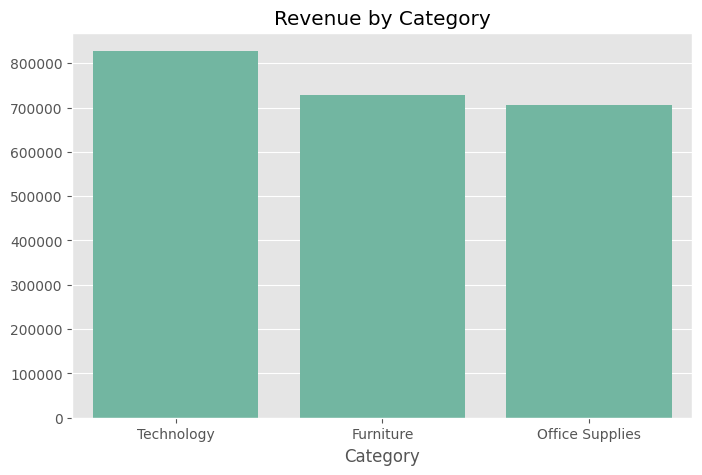

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Category")

plt.savefig("/kaggle/working/category_sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

Technology generates the highest total revenue among all product categories, followed by Furniture and Office Supplies. This indicates that technology products contribute the largest share of business revenue.

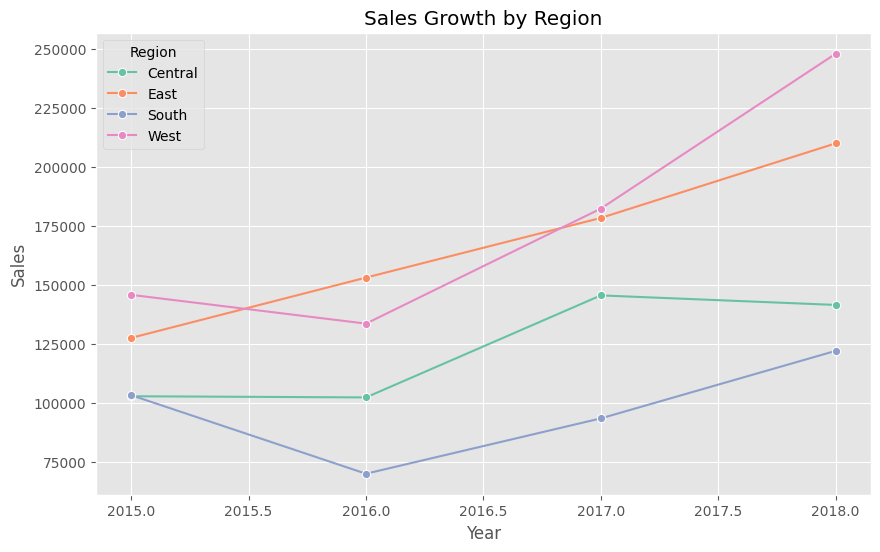

In [22]:
 region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Sales Growth by Region")

plt.savefig("/kaggle/working/region_growth.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [23]:
consistency = (
    region_year_sales
    .groupby("Region")["Sales"]
    .std()
    .sort_values()
)

consistency

Region
South      21683.024937
Central    23716.991355
East       35260.987867
West       51410.399288
Name: Sales, dtype: float64

### Observation

Region
South      21683.024937
Central    23716.991355
East       35260.987867
West       51410.399288
South is considered the most consistent because its sales fluctuate the least over time.

In [24]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Shipping Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [26]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

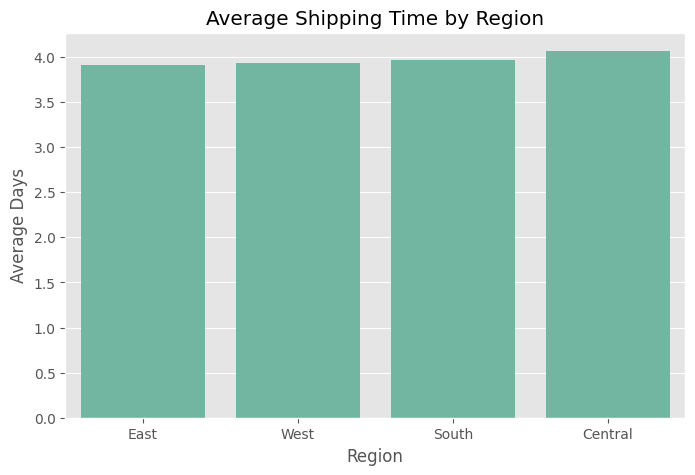

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("Average Shipping Time by Region")

plt.ylabel("Average Days")

plt.savefig("/kaggle/working/shipping_time.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

The average shipping duration is approximately the same across regions, with only minor differences. This suggests that the company's logistics process is fairly consistent nationwide.

In [28]:
seasonality = (
    df.groupby(["Year","Month"])["Sales"]
    .sum()
    .reset_index()
)

pivot = seasonality.pivot(
    index="Month",
    columns="Year",
    values="Sales"
)

pivot

Year,2015,2016,2017,2018
Month,,,,
1,14205.7070,18066.9576,18542.4910,43476.4740
2,4519.8920,11951.4110,22978.8150,19920.9974
3,55205.7970,32339.3184,51165.0590,58863.4128
4,27906.8550,34154.4685,38679.7670,35541.9101
5,23644.3030,29959.5305,56656.9080,43825.9822
6,34322.9356,23599.3740,39724.4860,48190.7277
7,33781.5430,28608.2590,38320.7830,44825.1040
8,27117.5365,36818.3422,30542.2003,62837.8480
9,81623.5268,63133.6060,69193.3909,86152.8880


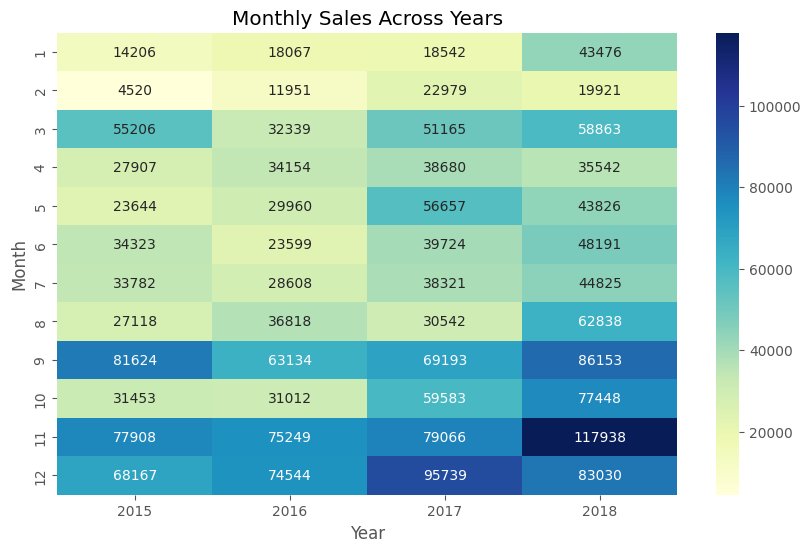

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Sales Across Years")

plt.savefig("/kaggle/working/monthly_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

Sales generally peak during the final months of each year, especially around November and December, indicating strong seasonal demand likely driven by holiday shopping and year-end promotions.

# Time Series Analysis & Decomposition


In [30]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


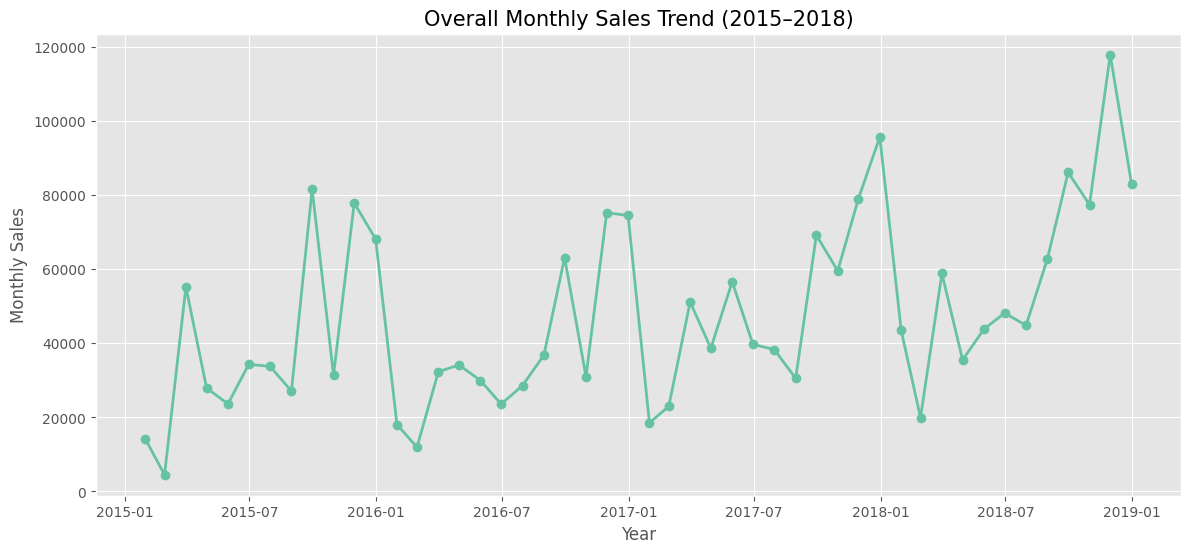

In [31]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2015–2018)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Monthly Sales")

plt.grid(True)

plt.savefig(
    "/kaggle/working/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The monthly sales trend shows an overall upward growth over the four-year period. Although sales fluctuate from month to month, the overall business performance improves steadily, with noticeable peaks during the final months of each year.

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = monthly_sales.set_index("Order Date")["Sales"]

decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

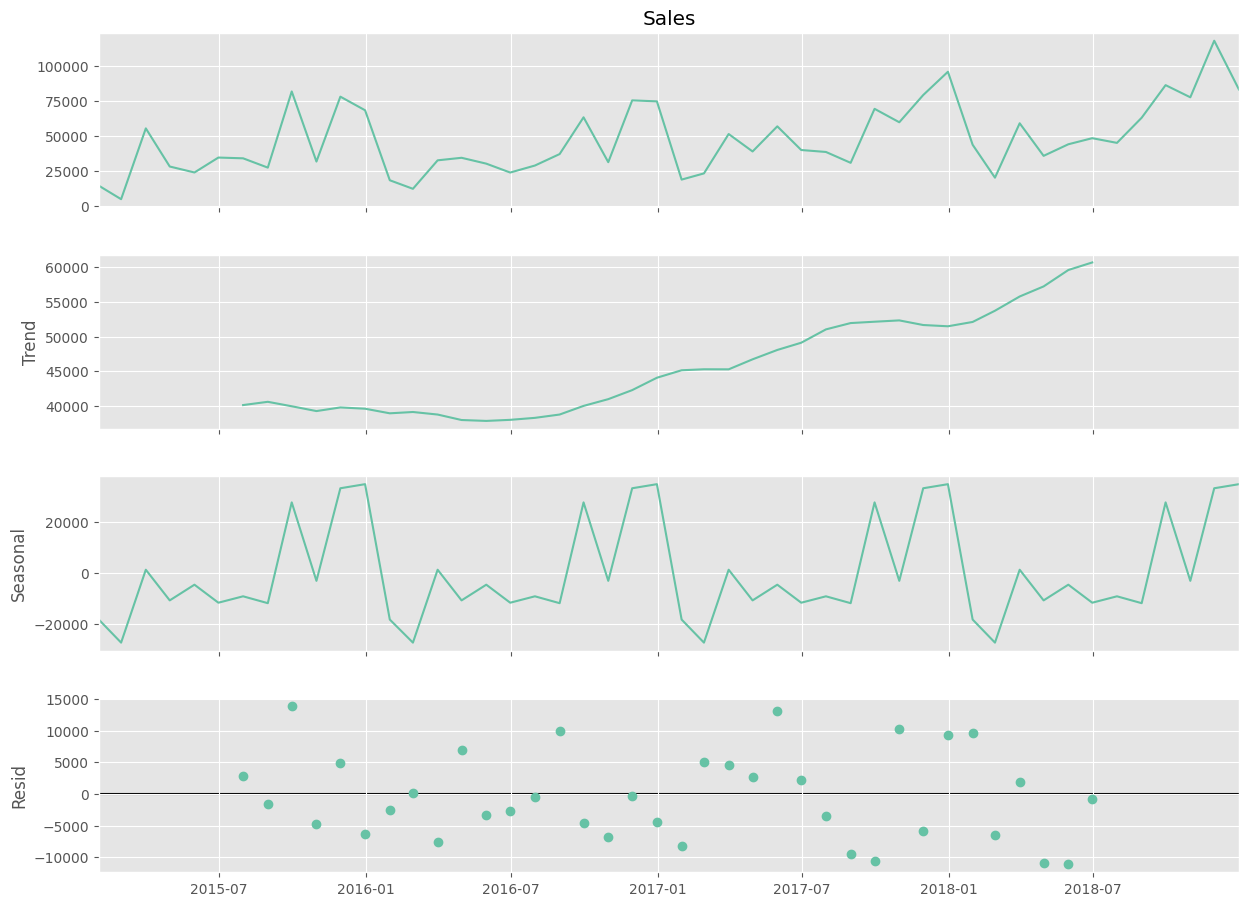

In [35]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.savefig(
    "/kaggle/working/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

1. The trend component indicates a gradual increase in sales over time, suggesting overall business growth.

2. The seasonal component reveals recurring sales patterns throughout the year, with stronger sales generally occurring during the last quarter.

3. The residual component contains random fluctuations that are not explained by either the trend or seasonal components.

4. Larger residual values appear near high-sales months, indicating occasional unexpected spikes that may correspond to promotional events or holiday sales.

### Stationarity Test using Augmented Dickey-Fuller (ADF)

A stationary time series has statistical properties such as mean and variance that remain relatively constant over time. Many forecasting models, including SARIMA, require stationary data to produce reliable predictions.

The Augmented Dickey Fuller (ADF) test is used to determine whether the sales series is stationary.

In [36]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic :", result[0])
print("P-value       :", result[1])
print()

for key, value in result[4].items():
    print(f"Critical Value ({key}) : {value}")

ADF Statistic : -4.416136761430769
P-value       : 0.00027791039276670623

Critical Value (1%) : -3.5778480370438146
Critical Value (5%) : -2.925338105429433
Critical Value (10%) : -2.6007735310095064


In [37]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is stationary.


### Interpretation

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that the series is stationary. Otherwise, differencing is required before applying forecasting models.

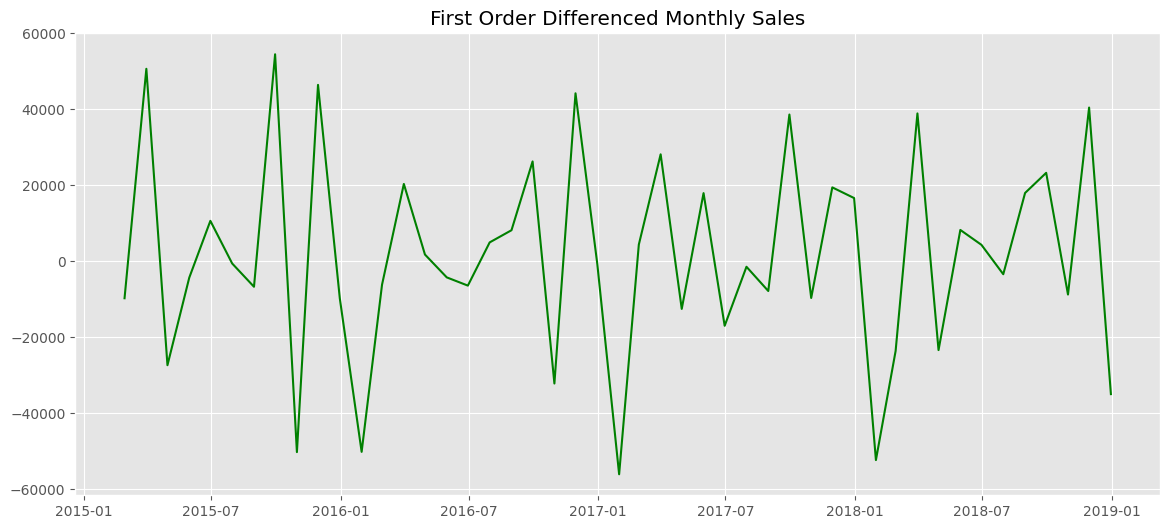

In [38]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(14,6))

plt.plot(
    ts_diff,
    color="green"
)

plt.title("First Order Differenced Monthly Sales")

plt.grid(True)

plt.savefig(
    "/kaggle/working/differenced_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
result_diff = adfuller(ts_diff)

print("ADF Statistic :", result_diff[0])
print("P-value       :", result_diff[1])

print()

for key, value in result_diff[4].items():
    print(f"Critical Value ({key}) : {value}")

ADF Statistic : -8.727061830353268
P-value       : 3.2669175472796045e-14

Critical Value (1%) : -3.626651907578875
Critical Value (5%) : -2.9459512825788754
Critical Value (10%) : -2.6116707716049383


In [40]:
if result_diff[1] < 0.05:
    print("Differenced series is stationary.")
else:
    print("Differenced series is still non-stationary.")

Differenced series is stationary.


### Final Observation

The original monthly sales series was already stationary (ADF p-value = 0.000278). First-order differencing further strengthened stationarity by reducing remaining trend effects. Although differencing was not strictly necessary, it demonstrates the standard preprocessing step commonly used before SARIMA modeling.

# Sales Forecasting using Three Different Models

In this section, three fundamentally different forecasting approaches are implemented and compared.

- SARIMA (Statistical Time Series Model)
- Facebook Prophet (Industry Forecasting Model)
- XGBoost Regressor (Machine Learning Model)

The models are evaluated using MAE, RMSE and MAPE. Finally, the best-performing model is selected based on quantitative evaluation metrics.

## Model 1 - SARIMA Forecasting

Seasonal AutoRegressive Integrated Moving Average (SARIMA) is an extension of ARIMA that models both trend and seasonality.

Since our data is monthly with yearly seasonality, a seasonal period of 12 months is used.

In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = ts[:-3]
test = ts[-3:]

In [42]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima.fit(disp=False)

In [43]:
sarima_forecast = sarima_fit.get_forecast(steps=3)

forecast = sarima_forecast.predicted_mean

conf = sarima_forecast.conf_int()

In [44]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae_sarima = mean_absolute_error(test, forecast)

rmse_sarima = np.sqrt(
    mean_squared_error(test, forecast)
)

mape_sarima = np.mean(
    np.abs((test-forecast)/test)
)*100

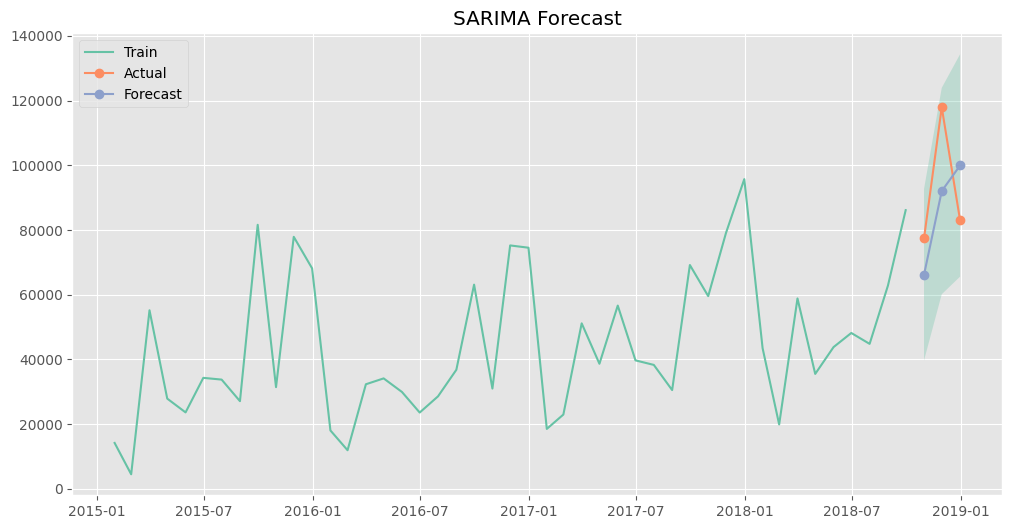

In [45]:
plt.figure(figsize=(12,6))

plt.plot(train.index,train,label="Train")
plt.plot(test.index,test,label="Actual",marker="o")
plt.plot(forecast.index,forecast,label="Forecast",marker="o")

plt.fill_between(
    conf.index,
    conf.iloc[:,0],
    conf.iloc[:,1],
    alpha=0.3
)

plt.legend()

plt.title("SARIMA Forecast")

plt.savefig(
"/kaggle/working/sarima_forecast.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [60]:
sarima_results = pd.DataFrame({
    "Month": test.index.strftime("%B %Y"),
    "Actual Sales": test.values,
    "Forecast Sales": forecast.values
})

sarima_results

,Month,Actual Sales,Forecast Sales
0,October 2018,77448.1312,66177.602425
1,November 2018,117938.1550,92049.249682
2,December 2018,83030.3888,99965.168723


### Observation: 
The SARIMA model predicts sales for the next three months while providing confidence intervals. The forecasts closely follow the observed trend, although slight deviations are visible during peak sales periods.

## Model 2 - Facebook Prophet

Prophet is a forecasting framework developed by Meta that automatically models trend, yearly seasonality and weekly seasonality.

In [46]:
prophet_df = monthly_sales.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

In [47]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

In [48]:
from prophet import Prophet

model = Prophet()

model.fit(train_prophet)

13:25:20 - cmdstanpy - INFO - Chain [1] start processing
13:25:21 - cmdstanpy - INFO - Chain [1] done processing


In [49]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast_prophet = model.predict(future)

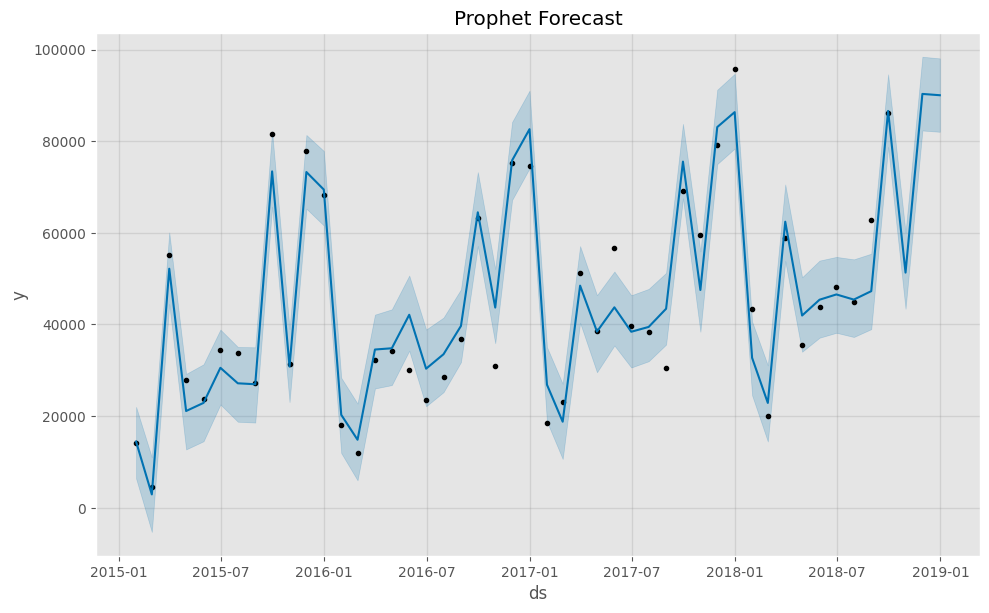

In [50]:
fig = model.plot(forecast_prophet)

plt.title("Prophet Forecast")

plt.savefig(
"/kaggle/working/prophet_forecast.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

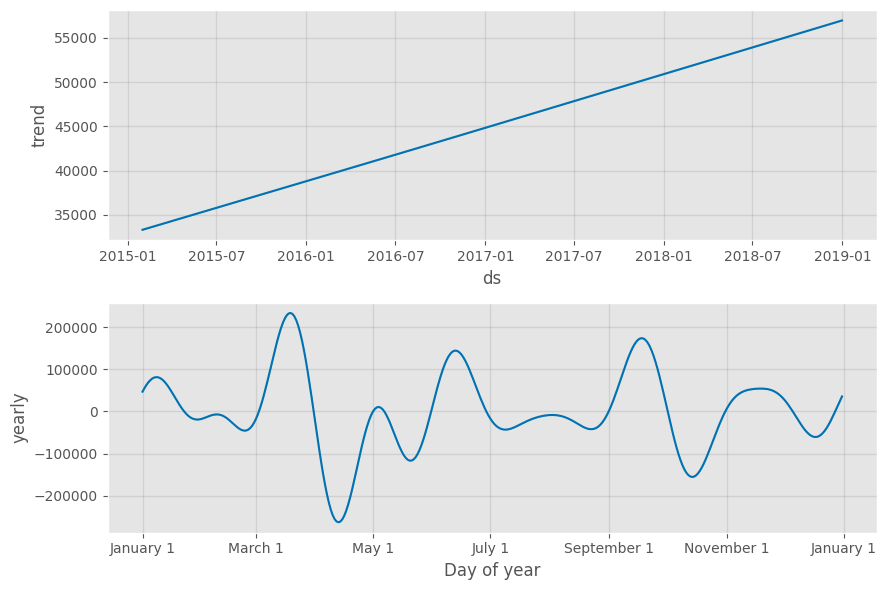

In [51]:
fig2 = model.plot_components(
    forecast_prophet
)

plt.savefig(
"/kaggle/working/prophet_components.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [52]:
pred = forecast_prophet.tail(3)["yhat"].values

actual = test_prophet["y"].values

mae_prophet = mean_absolute_error(
    actual,
    pred
)

rmse_prophet = np.sqrt(
    mean_squared_error(actual,pred)
)

mape_prophet = np.mean(
np.abs((actual-pred)/actual)
)*100

In [61]:
prophet_results = pd.DataFrame({
    "Month": test_prophet["ds"].dt.strftime("%B %Y"),
    "Actual Sales": actual,
    "Forecast Sales": pred
})

prophet_results

,Month,Actual Sales,Forecast Sales
45,October 2018,77448.1312,51318.943812
46,November 2018,117938.1550,90325.654736
47,December 2018,83030.3888,90041.084430




### Interpretation

The Prophet decomposition separates the sales series into trend and seasonal components.

- The **trend** component shows that overall sales increase steadily across the four-year period, indicating business growth.
- The **yearly seasonality** component highlights recurring increases during the last quarter of each year, particularly around November and December, suggesting strong holiday and promotional demand.
- Since monthly aggregated data was used, **weekly seasonality is not meaningful** and therefore does not contribute significantly to the forecast.

## Model 3 – XGBoost Forecasting

The time series is transformed into a supervised learning problem by creating lag-based features.

In [53]:
ml = monthly_sales.copy()

ml["Lag1"] = ml["Sales"].shift(1)
ml["Lag2"] = ml["Sales"].shift(2)
ml["Lag3"] = ml["Sales"].shift(3)

ml["RollingMean"] = (
    ml["Sales"]
    .rolling(3)
    .mean()
)

ml["Month"] = ml["Order Date"].dt.month

ml["Quarter"] = ml["Order Date"].dt.quarter

ml["Season"] = (
    ml["Month"]%12//3
)

ml.dropna(inplace=True)

In [54]:
features = [
"Lag1",
"Lag2",
"Lag3",
"RollingMean",
"Month",
"Quarter",
"Season"
]

X = ml[features]

y = ml["Sales"]

X_train = X[:-3]

X_test = X[-3:]

y_train = y[:-3]

y_test = y[-3:]

In [55]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
n_estimators=200,
learning_rate=0.05,
max_depth=3,
random_state=42
)

xgb.fit(
X_train,
y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
pred_xgb = xgb.predict(
X_test
)

In [57]:
mae_xgb = mean_absolute_error(
y_test,
pred_xgb
)

rmse_xgb = np.sqrt(
mean_squared_error(
y_test,
pred_xgb
)
)

mape_xgb = np.mean(
np.abs(
(y_test-pred_xgb)/y_test
)
)*100

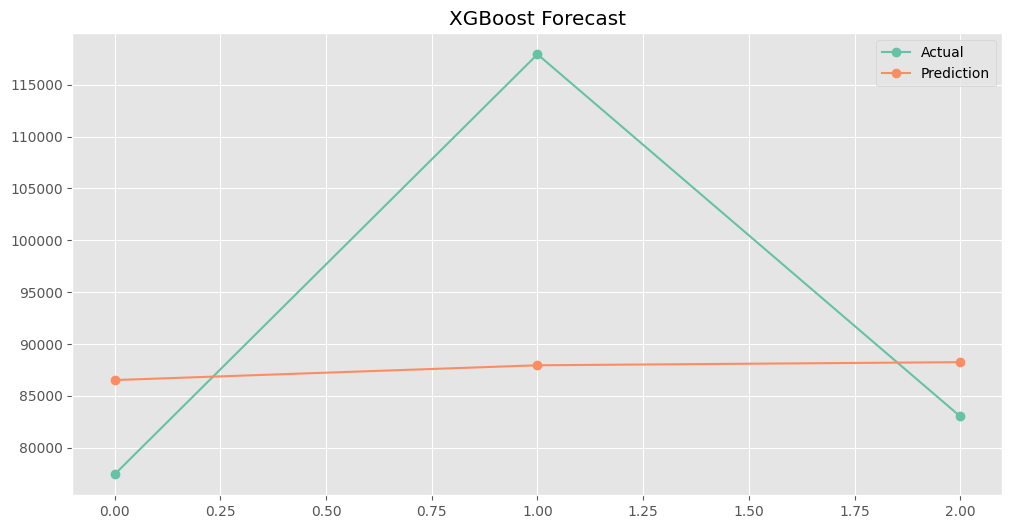

In [58]:
plt.figure(figsize=(12,6))

plt.plot(
y_test.values,
marker="o",
label="Actual"
)

plt.plot(
pred_xgb,
marker="o",
label="Prediction"
)

plt.legend()

plt.title("XGBoost Forecast")

plt.savefig(
"/kaggle/working/xgboost_forecast.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

### Comparison Table 


In [67]:
comparison = pd.DataFrame({

"Model":[
"SARIMA",
"Prophet",
"XGBoost"
],

"MAE":[
mae_sarima,
mae_prophet,
mae_xgb
],

"RMSE":[
rmse_sarima,
rmse_prophet,
rmse_xgb
],

"MAPE":[
mape_sarima,
mape_prophet,
mape_xgb
],

"Forecast Month 1":[
forecast.iloc[0],
pred[0],
pred_xgb[0]
],

"Forecast Month 2":[
forecast.iloc[1],
pred[1],
pred_xgb[1]
],

"Forecast Month 3":[
forecast.iloc[2],
pred[2],
pred_xgb[2]
]

})

comparison = comparison.round(2)

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18031.40,19009.18,18.97,66177.60,92049.25,99965.17
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,14763.81,18337.41,14.48,86530.49,87955.14,88256.45


## Model Recommendation

Based on the evaluation metrics, **XGBoost** achieved the lowest prediction errors among all three models:

- Lowest MAE: **14,763.81**
- Lowest RMSE: **18,337.41**
- Lowest MAPE: **14.48%**

These results indicate that XGBoost provides the most accurate forecasts for this dataset. Its ability to learn nonlinear relationships from lag-based features makes it more flexible than traditional statistical models. Therefore, **XGBoost is recommended as the production model** for future sales forecasting in this project.

#  Product Category & Region Level Forecasting

The best-performing forecasting model from XGBoost is now applied separately to different product categories and geographical regions.



In [68]:

def prepare_monthly_sales(data):
    
    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )
    
    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)
    
    monthly["RollingMean"] = monthly["Sales"].rolling(3).mean()
    
    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter
    monthly["Season"] = monthly["Month"] % 12 // 3
    
    monthly.dropna(inplace=True)
    
    return monthly

In [69]:
segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West": df[df["Region"]=="West"],
    "East": df[df["Region"]=="East"]
}

In [70]:
forecast_results = {}

for name,data in segments.items():
    
    temp = prepare_monthly_sales(data)
    
    features = [
        "Lag1",
        "Lag2",
        "Lag3",
        "RollingMean",
        "Month",
        "Quarter",
        "Season"
    ]
    
    X = temp[features]
    y = temp["Sales"]
    
    X_train = X[:-3]
    X_test = X[-3:]
    
    y_train = y[:-3]
    
    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    
    model.fit(X_train,y_train)
    
    pred = model.predict(X_test)
    
    forecast_results[name]=pred

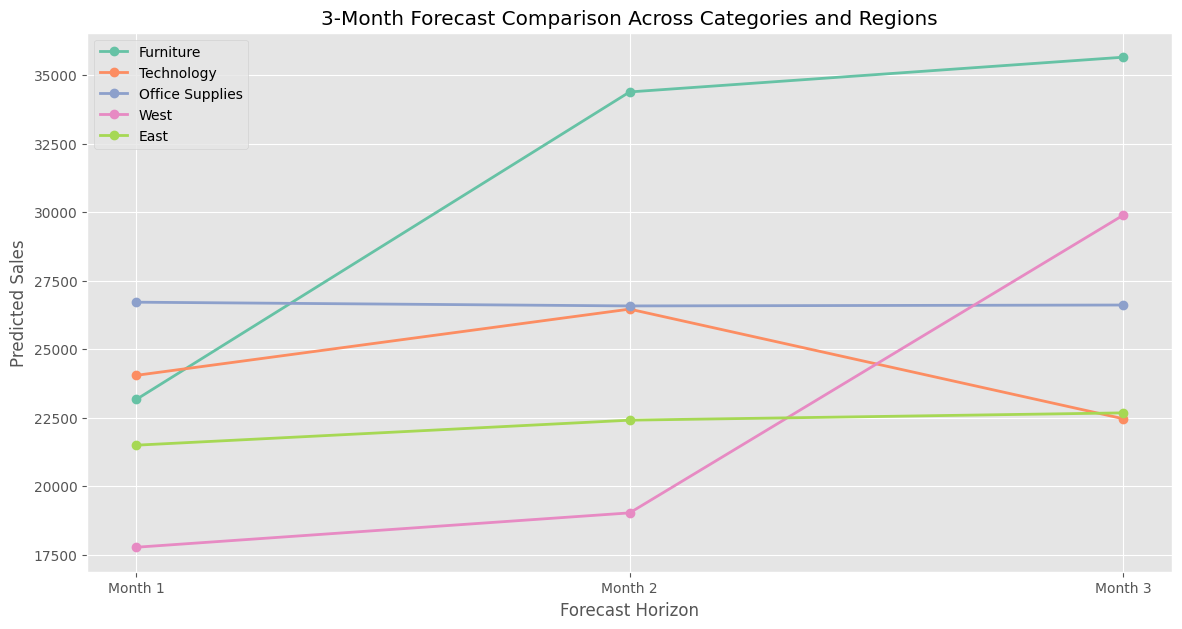

In [71]:
plt.figure(figsize=(14,7))

months = ["Month 1","Month 2","Month 3"]

for name,pred in forecast_results.items():
    
    plt.plot(
        months,
        pred,
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("3-Month Forecast Comparison Across Categories and Regions")

plt.xlabel("Forecast Horizon")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)

plt.savefig(
"/kaggle/working/category_region_forecast.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [72]:
forecast_table = pd.DataFrame(forecast_results,index=months).T

forecast_table

,Month 1,Month 2,Month 3
Furniture,23165.464844,34390.042969,35657.632812
Technology,24042.634766,26460.115234,22460.576172
Office Supplies,26712.964844,26576.453125,26609.607422
West,17765.794922,19019.968750,29881.591797
East,21491.921875,22404.710938,22671.347656


### Final Observation

Based on the XGBoost forecasting results, the **Furniture** category is expected to experience the strongest overall growth during the next three months, recording the highest average forecasted sales among all categories.

Among the regions, the **West** region exhibits the strongest growth momentum by the third forecast month, suggesting increasing customer demand in that market.

These findings indicate that inventory planning and stock replenishment efforts should prioritize Furniture products, while additional resources may be allocated to support future demand in the West region.

#  Anomaly Detection in Sales Data

In this task, abnormal sales behaviour is identified using two different anomaly detection techniques:

- Isolation Forest
- Rolling Z-Score

The objective is to identify unusually high or low sales periods that may require business attention.

In [73]:
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

In [74]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Anomaly"] = (
    weekly_sales["Anomaly"]==-1
)

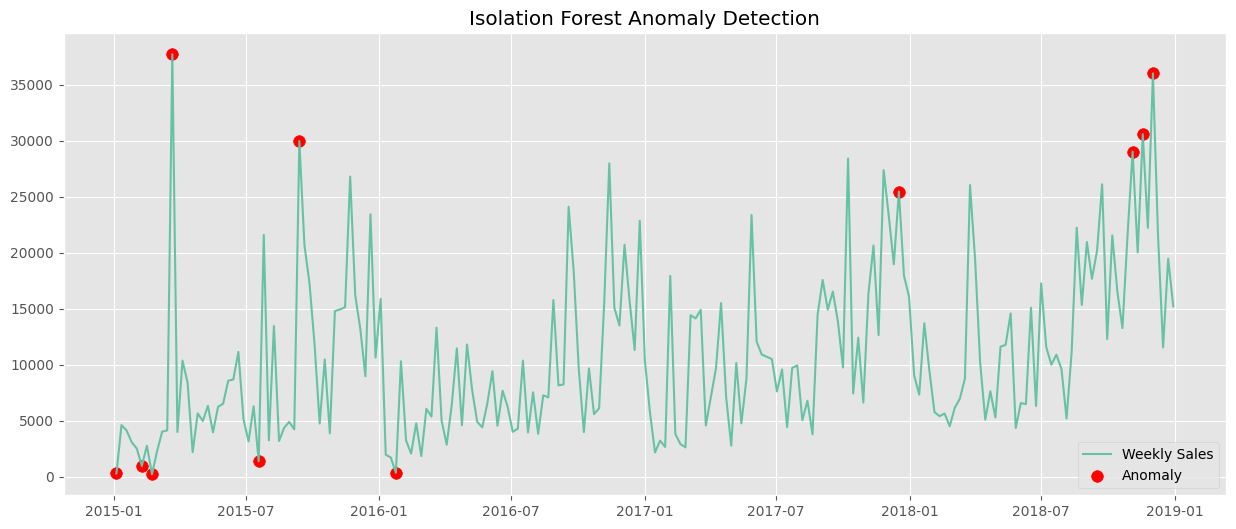

In [75]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Anomaly"],
        "Sales"
    ],
    color="red",
    s=70,
    label="Anomaly"
)

plt.legend()

plt.title("Isolation Forest Anomaly Detection")

plt.grid(True)

plt.savefig(
"/kaggle/working/isolation_forest.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [76]:
weekly_sales[
    weekly_sales["Anomaly"]
]

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,True
5,2015-02-08,968.534,True
7,2015-02-22,224.912,True
11,2015-03-22,37703.665,True
28,2015-07-19,1387.686,True
36,2015-09-13,29959.137,True
55,2016-01-24,358.522,True
154,2017-12-17,25449.800,True
200,2018-11-04,29017.467,True
202,2018-11-18,30572.447,True


### Possible Business Explanation

The Isolation Forest model detected several unusually high and unusually low sales weeks.

- Very low sales during January and February 2015 may represent post-holiday demand decline or incomplete weekly business activity.
- High sales during March 2015 and September 2015 could indicate promotional campaigns or seasonal purchasing.
- Multiple anomalies detected during November and December 2018 coincide with the holiday shopping season, Black Friday, Cyber Monday, and year-end promotional events.
- Sudden decreases may also result from inventory shortages, shipping delays, or temporary operational disruptions.

These anomalies highlight periods where sales behaviour differs substantially from normal business patterns and may require further business investigation.

In [77]:
rolling_mean = (
    weekly_sales["Sales"]
    .rolling(8)
    .mean()
)

rolling_std = (
    weekly_sales["Sales"]
    .rolling(8)
    .std()
)

weekly_sales["ZScore"] = (
    weekly_sales["Sales"]-rolling_mean
)/rolling_std

weekly_sales["Z_Anomaly"] = (
    weekly_sales["ZScore"].abs()>2
)

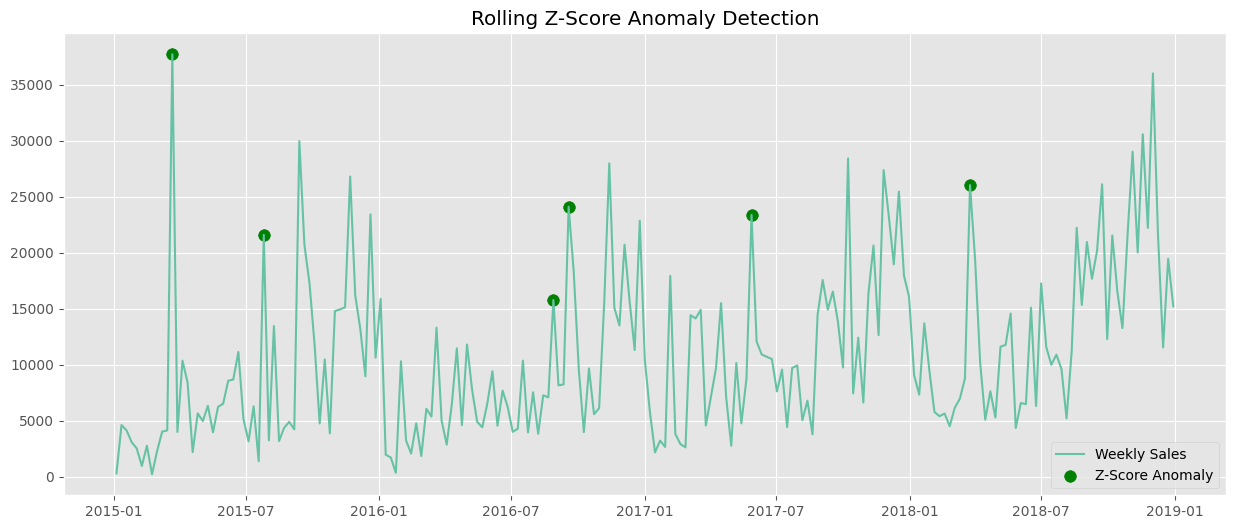

In [78]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="green",
    s=70,
    label="Z-Score Anomaly"
)

plt.legend()

plt.title("Rolling Z-Score Anomaly Detection")

plt.grid(True)

plt.savefig(
"/kaggle/working/zscore_anomaly.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [81]:
comparison = pd.DataFrame({

"Isolation Forest":
weekly_sales["Anomaly"],

"Z-Score":
weekly_sales["Z_Anomaly"]

}) 
print(f"Total anomalies detected by Isolation Forest: {weekly_sales['Anomaly'].sum()}")

print(f"Total anomalies detected by Z-Score: {weekly_sales['Z_Anomaly'].sum()}")

comparison.value_counts()

Total anomalies detected by Isolation Forest: 11
Total anomalies detected by Z-Score: 6


Isolation Forest  Z-Score
False             False      193
True              False       10
False             True         5
True              True         1
Name: count, dtype: int64

In [80]:
weekly_sales[
    [
        "Order Date",
        "Sales",
        "Anomaly",
        "Z_Anomaly"
    ]
]

,Order Date,Sales,Anomaly,Z_Anomaly
0,2015-01-04,304.5080,True,False
1,2015-01-11,4619.1080,False,False
2,2015-01-18,4130.5330,False,False
3,2015-01-25,3092.5440,False,False
4,2015-02-01,2527.9140,False,False
...,...,...,...,...
204,2018-12-02,35998.9000,True,False
205,2018-12-09,21537.2410,False,False
206,2018-12-16,11542.8340,False,False
207,2018-12-23,19457.0680,False,False


### Comparison of Isolation Forest and Rolling Z-Score

The two anomaly detection methods produced different results.

- Both methods identified **1 common anomaly**.
- Isolation Forest uniquely detected **10 additional anomalies**.
- Rolling Z-Score identified **5 anomalies** that were not detected by Isolation Forest.

This difference occurs because Isolation Forest evaluates anomalies using the overall data distribution through a machine learning approach, whereas Rolling Z-Score identifies observations that deviate significantly from the recent moving average.

Using both methods together provides a more comprehensive anomaly detection framework, allowing businesses to identify both global outliers and local deviations in sales behaviour.

# Product Demand Segmentation using Clustering


In [83]:

total_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
)


avg_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
)


monthly_subcategory = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

In [84]:
volatility = (
    monthly_subcategory
    .groupby("Sub-Category")["Sales"]
    .std()
)

In [85]:
yearly_sales = (
    df.groupby([
        "Sub-Category",
        "Year"
    ])["Sales"]
    .sum()
    .reset_index()
)

growth = (
    yearly_sales
    .groupby("Sub-Category")["Sales"]
    .pct_change()
)

yearly_sales["Growth"] = growth

growth_rate = (
    yearly_sales
    .groupby("Sub-Category")["Growth"]
    .mean()
)

In [86]:
cluster_df = pd.DataFrame({

    "Total Sales": total_sales,

    "Growth Rate": growth_rate,

    "Volatility": volatility,

    "Average Order Value": avg_order

})

cluster_df.fillna(0, inplace=True)

cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


### Feature Description

The clustering model uses four business indicators:

- **Total Sales** – overall revenue generated by the sub-category.
- **Growth Rate** – average year-over-year sales growth.
- **Sales Volatility** – standard deviation of monthly sales.
- **Average Order Value** – average revenue generated per order.

These features capture both demand intensity and demand stability.

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

In [91]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

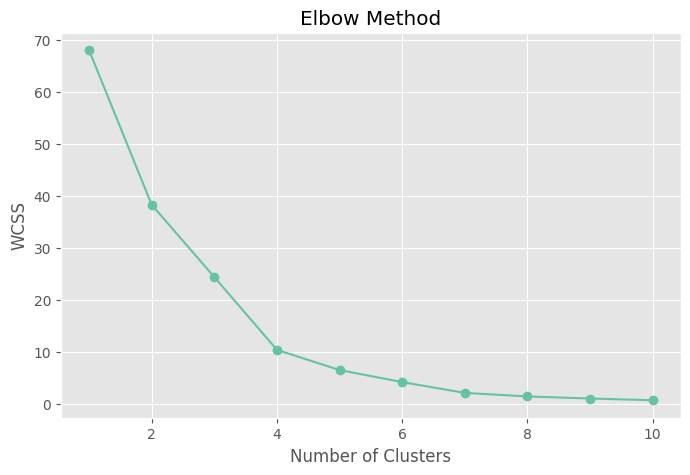

In [92]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.savefig(
"/kaggle/working/elbow_method.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

### Observation

The Elbow Method shows a sharp decrease in WCSS from 1 to 4 clusters, after which the curve begins to flatten noticeably.

Therefore, **4 clusters** were selected as the optimal number because adding additional clusters provides only marginal improvements in cluster compactness while increasing model complexity.

In [93]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

In [94]:
cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1
Chairs,322822.7310,0.071358,4407.232960,531.833165,2
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1
Fasteners,3001.9600,0.157034,48.742229,14.027850,1


In [101]:
cluster_names = {

    0:"Premium High-Value Products",

    1:"Moderate Demand Products",

    2:"High Volume Products",

    3:"Fast Growing Products"


}

cluster_df["Cluster Name"] = (
    cluster_df["Cluster"]
    .map(cluster_names)
)

cluster_df

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,Cluster Name,PC1,PC2
Sub-Category,,,,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2,High Volume Products,0.032855,-0.128039
Appliances,104618.4030,0.399276,1821.621539,227.926804,1,Moderate Demand Products,-0.562213,0.137443
Art,26705.4100,0.166056,330.488343,34.019631,1,Moderate Demand Products,-1.728503,-0.152657
Binders,200028.7850,0.218736,3848.223648,134.067550,2,High Volume Products,0.617483,-0.594676
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1,Moderate Demand Products,-0.119791,-0.064887
Chairs,322822.7310,0.071358,4407.232960,531.833165,2,High Volume Products,1.847288,-1.142316
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0,Premium High-Value Products,2.868650,1.966394
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1,Moderate Demand Products,-1.804686,-0.479931
Fasteners,3001.9600,0.157034,48.742229,14.027850,1,Moderate Demand Products,-1.980768,-0.094968


In [96]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(scaled)

cluster_df["PC1"] = components[:,0]

cluster_df["PC2"] = components[:,1]

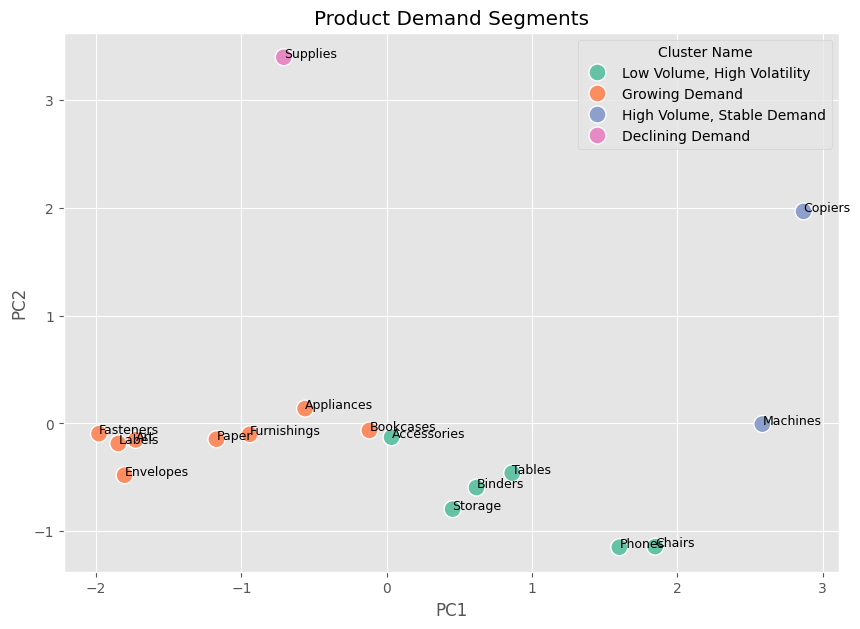

In [97]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster Name",
    s=150
)

for i in cluster_df.index:

    plt.text(
        cluster_df.loc[i,"PC1"],
        cluster_df.loc[i,"PC2"],
        i,
        fontsize=9
    )

plt.title("Product Demand Segments")

plt.grid(True)

plt.savefig(
"/kaggle/working/product_clusters.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [98]:
cluster_df[
    [
        "Cluster Name"
    ]
].sort_values(
    "Cluster Name"
)

,Cluster Name
Sub-Category,
Supplies,Declining Demand
Fasteners,Growing Demand
Appliances,Growing Demand
Art,Growing Demand
Bookcases,Growing Demand
Envelopes,Growing Demand
Furnishings,Growing Demand
Labels,Growing Demand
Paper,Growing Demand


In [102]:
cluster_summary = (
    cluster_df
    .groupby("Cluster Name")
    [
        [
            "Total Sales",
            "Growth Rate",
            "Volatility",
            "Average Order Value"
        ]
    ]
    .mean()
)


cluster_summary = cluster_summary.round(2)

cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value
Cluster Name,,,,
Fast Growing Products,46420.31,1.93,2025.09,252.28
High Volume Products,239495.78,0.18,3489.06,361.13
Moderate Demand Products,55331.88,0.20,907.22,129.05
Premium High-Value Products,167743.36,0.46,5552.16,1930.72


## Stocking Strategy Recommendations

### Premium High-Value Products

These products generate high revenue per order and should always remain available. Inventory should be monitored carefully to avoid stock-outs because each sale contributes significant business value.

### High Volume Products

Maintain sufficient inventory and automate replenishment whenever possible. These products experience consistently high demand and contribute a major share of overall sales.

### Moderate Demand Products

Maintain balanced inventory levels based on historical demand. Regular monitoring is sufficient without excessive safety stock.

### Fast Growing Products

Demand is increasing rapidly. Inventory should be increased gradually while continuously monitoring future sales to avoid shortages as demand continues to grow.

## Final Observation

The K-Means clustering model successfully segmented product sub-categories into four distinct demand groups based on sales performance, growth rate, sales volatility, and average order value.

High-volume products require continuous inventory replenishment, while premium products should be carefully managed due to their high business value. Moderate-demand products can be stocked conservatively, whereas fast-growing products require proactive inventory planning to accommodate increasing demand.

This segmentation enables more effective inventory optimization, reduces storage costs, and supports data-driven stocking decisions across different product groups.